Hola **Iris**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

**Tip**: Para mejorar la presentación en tus notebooks te recomiendo siempre dejar al inicio del mismo una **celda tipo markdown** donde redactes un título descriptivo y una breve introducción para que sea claro desde el inicio lo que se realizará
</div>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from scipy import stats


Solo prepara el entorno cargando las librerías necesarias para un análisis típico que incluye:
Cargar y manipular datos → pandas
Realizar cálculos numéricos → numpy
Graficar resultados → matplotlib
Trabajar con fechas → datetime
Aplicar pruebas estadísticas → scipy.stats

In [2]:

hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

hypotheses.columns = hypotheses.columns.str.strip().str.lower()

hypotheses.head()


,hypothesis,reach,impact,confidence,effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


Carga un archivo CSV, limpia los nombres de las columnas y muestra las primeras filas para verificar que los datos se hayan cargado correctamente.

In [3]:

num_cols = ['reach', 'impact', 'confidence', 'effort']

missing_cols = [c for c in num_cols if c not in hypotheses.columns]
if missing_cols:
    raise KeyError(f"Faltan columnas esperadas en el dataset: {missing_cols}")

for col in num_cols:
    hypotheses[col] = pd.to_numeric(hypotheses[col], errors='coerce')

hypotheses[num_cols].info()

hypotheses[num_cols].isna().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   reach       9 non-null      int64
 1   impact      9 non-null      int64
 2   confidence  9 non-null      int64
 3   effort      9 non-null      int64
dtypes: int64(4)
memory usage: 416.0 bytes


reach         0
impact        0
confidence    0
effort        0
dtype: int64

Define qué columnas deben ser numéricas.
Comprueba que existan en el DataFrame.
Convierte esas columnas a tipo numérico, reemplazando datos inválidos con NaN.
Muestra información del estado de esas columnas.
Cuenta los valores faltantes para análisis de calidad de datos.

In [4]:


hypotheses.loc[hypotheses['effort'] == 0, 'effort'] = np.nan

hypotheses['ice'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']
hypotheses['rice'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

hypotheses[['hypothesis', 'reach', 'impact', 'confidence', 'effort', 'ice', 'rice']].head()



,hypothesis,reach,impact,confidence,effort,ice,rice
0,Add two new channels for attracting traffic. T...,3,10,8,6.0,13.333333,40.0
1,Launch your own delivery service. This will sh...,2,5,4,10.0,2.000000,4.0
2,Add product recommendation blocks to the store...,8,3,7,3.0,7.000000,56.0
3,Change the category structure. This will incre...,8,3,3,8.0,1.125000,9.0
4,Change the background color on the main page. ...,3,1,1,1.0,1.000000,3.0


Limpia valores incorrectos de esfuerzo, calcula los puntajes ICE y RICE para priorizar hipótesis y muestra una vista previa de los resultados.

In [5]:
hypotheses['ice_rank'] = hypotheses['ice'].rank(ascending=False, method='min')
hypotheses['rice_rank'] = hypotheses['rice'].rank(ascending=False, method='min')
hypotheses['position_change'] = hypotheses['ice_rank'] - hypotheses['rice_rank']

rank_comparison = hypotheses[['hypothesis', 'ice', 'ice_rank', 'rice', 'rice_rank', 'position_change']].sort_values(by='position_change', ascending=False)

rank_comparison

,hypothesis,ice,ice_rank,rice,rice_rank,position_change
2,Add product recommendation blocks to the store...,7.000000,5.0,56.0,2.0,3.0
3,Change the category structure. This will incre...,1.125000,8.0,9.0,6.0,2.0
7,Add a subscription form to all the main pages....,11.200000,3.0,112.0,1.0,2.0
6,Show banners with current offers and sales on ...,8.000000,4.0,40.0,3.0,1.0
4,Change the background color on the main page. ...,1.000000,9.0,3.0,9.0,0.0
5,Add a customer review page. This will increase...,1.333333,7.0,4.0,7.0,0.0
0,Add two new channels for attracting traffic. T...,13.333333,2.0,40.0,3.0,-1.0
1,Launch your own delivery service. This will sh...,2.000000,6.0,4.0,7.0,-1.0
8,Launch a promotion that gives users discounts ...,16.200000,1.0,16.2,5.0,-4.0


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Iris, no es correcto presentar de esta forma un notebook. Hay varios puntos que se repiten en todas tus celdas y deben ser corregidos:

- No es buena práctica importar librerías que ya han sido importadas
- No es buena práctica utilizar `print` para redactar tus interpretaciones. Deberías utilizar **celdas markdown** cómo esta en la que se te deja el feedback para redactar textos extensos cómo conclusiones o interpretaciones
- El uso de un notebook es para evitar tener scripts de código extenso, debes separar cada paso de tus ejercicios en diferentes celdas y no tener celads tan extensas. Esto ayuda a la presentación y seguimiento de tu notebook. Siempre que muestres una salida deberías usar una celda diferente, si muestras una gráfica debería ser una celda por gráfica y siempre dejando la interpretación adecuada.
- Para las conclusiones finales debes una celda markdown también.

En caso de tener dudas o dificultades sobre el correcto uso de los notebooks te pediría contactar a tu tutor para que pueda explicarte de manera detallada, es importante tener claro el uso correcto de los notebooks ya que te acercas a tus proyectos finales.

Saludos!
</div>

Calcula los rankings (posiciones) de cada hipótesis según ICE y RICE.
Compara ambas posiciones.
Mide cuánto cambia la prioridad al cambiar de método.
Genera una tabla ordenada con esos cambios.

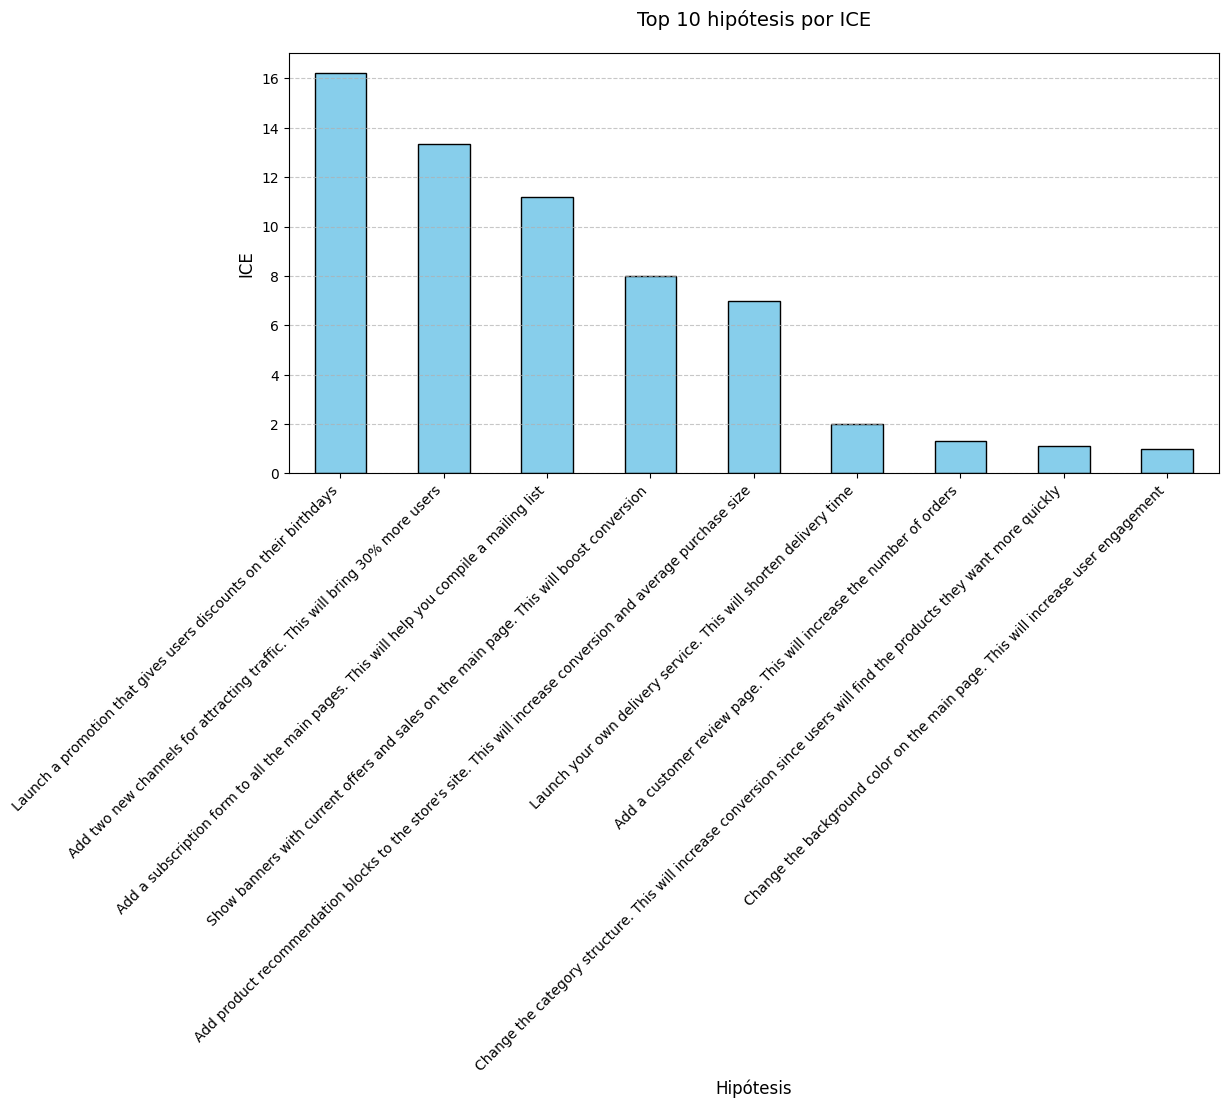

In [6]:


top_n = 10
by_ice = hypotheses.sort_values(by='ice', ascending=False).head(top_n).set_index('hypothesis')

plt.figure(figsize=(12, 7))
by_ice['ice'].plot(kind='bar', color='skyblue', edgecolor='black')

plt.title(f'Top {top_n} hipótesis por ICE', fontsize=14, pad=20)
plt.ylabel('ICE', fontsize=12)
plt.xlabel('Hipótesis', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.subplots_adjust(bottom=0.3, top=0.9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Selecciona las 10 mejores hipótesis según ICE.
Las ordena de mayor a menor.
Genera un gráfico de barras elegante y legible.
Facilita visualizar rápidamente cuáles hipótesis tienen mayor prioridad según su puntaje ICE.

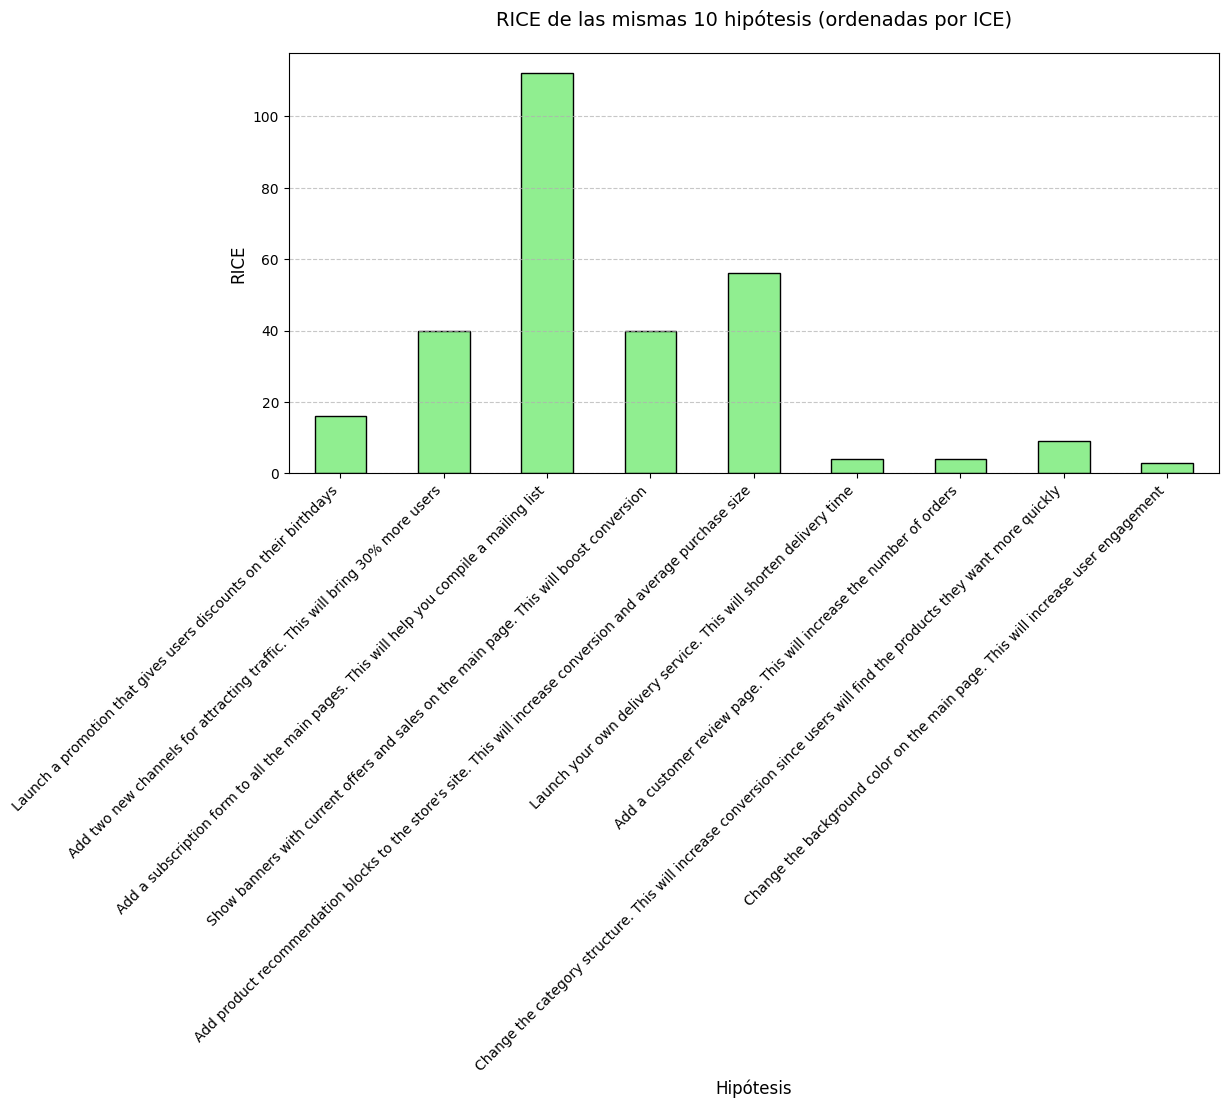

In [7]:


plt.figure(figsize=(12, 7))
by_ice['rice'].plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title(f'RICE de las mismas {top_n} hipótesis (ordenadas por ICE)', fontsize=14, pad=20)
plt.ylabel('RICE', fontsize=12)
plt.xlabel('Hipótesis', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.subplots_adjust(bottom=0.3, top=0.9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



Usa las mismas hipótesis seleccionadas previamente por ICE.
Grafica sus puntajes RICE.
Permite comparar visualmente cómo cambian las prioridades cuando se usa RICE en lugar de ICE.
Produce una gráfica clara y estilizada en barras.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo con el cálculo para la priorización con los diferentes frameworks! Con las gráficas se puede comparar mejor las diferencias
</div>

In [8]:
top_ice_changes = rank_comparison[rank_comparison['hypothesis'].isin(by_ice.index)].copy()

top_ice_changes.sort_values(by='ice_rank')

,hypothesis,ice,ice_rank,rice,rice_rank,position_change
8,Launch a promotion that gives users discounts ...,16.200000,1.0,16.2,5.0,-4.0
0,Add two new channels for attracting traffic. T...,13.333333,2.0,40.0,3.0,-1.0
7,Add a subscription form to all the main pages....,11.200000,3.0,112.0,1.0,2.0
6,Show banners with current offers and sales on ...,8.000000,4.0,40.0,3.0,1.0
2,Add product recommendation blocks to the store...,7.000000,5.0,56.0,2.0,3.0
1,Launch your own delivery service. This will sh...,2.000000,6.0,4.0,7.0,-1.0
5,Add a customer review page. This will increase...,1.333333,7.0,4.0,7.0,0.0
3,Change the category structure. This will incre...,1.125000,8.0,9.0,6.0,2.0
4,Change the background color on the main page. ...,1.000000,9.0,3.0,9.0,0.0


Toma únicamente las hipótesis que fueron top según ICE.
Las cruza con la tabla de cambios de ranking (ICE vs RICE).
Las ordena por su posición original de ICE para revisarlas fácilmente.
En otras palabras: Permite analizar cómo las mejores hipótesis según ICE cambian de posición cuando se evalúan con RICE.

In [9]:
rank_comparison.to_csv('hypotheses_rank_comparison.csv', index=False)

Guarda la tabla rank_comparison como un archivo CSV llamado hypotheses_rank_comparison.csv, sin incluir el índice.

In [10]:

orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

orders.columns = orders.columns.str.strip()
visits.columns = visits.columns.str.strip()

orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

orders['group'] = orders['group'].astype(str)
visits['group'] = visits['group'].astype(str)


Carga los datasets de órdenes y visitas.
Limpia los nombres de las columnas.
Convierte las fechas al formato correcto.
Estandariza los valores del grupo para que sean texto.
Es un paso de preprocesamiento fundamental para cualquier análisis A/B.

In [11]:

dups = orders.groupby('visitorId')['group'].nunique()
visitor_in_both = dups[dups > 1].index.tolist()

if visitor_in_both:
    print(f"Se eliminarán {len(visitor_in_both)} usuarios que aparecen en ambos grupos.")
    orders = orders[~orders['visitorId'].isin(visitor_in_both)]


Se eliminarán 58 usuarios que aparecen en ambos grupos.


En un A/B test, cada usuario debe pertenecer solo a un grupo.
Si un usuario aparece en A y B:
Contamina los resultados.
Aumenta el riesgo de sesgos.
Rompe la condición de independencia entre los grupos.
Por eso se eliminan completamente esos usuarios.


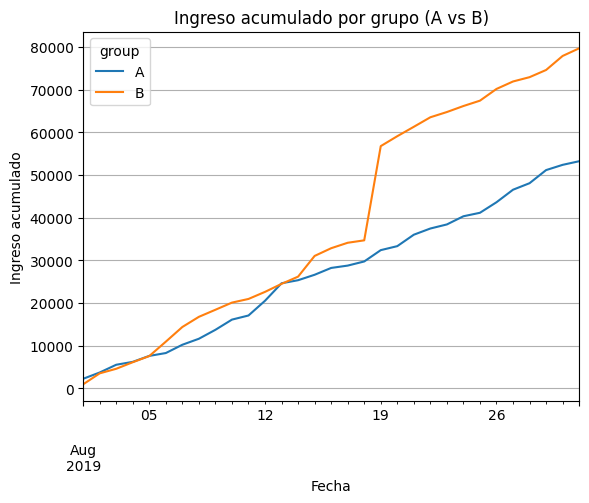

In [12]:


orders_sorted = orders.sort_values('date')
cumulative = (orders_sorted
              .groupby(['date', 'group'])
              .agg({'revenue': 'sum'})
              .reset_index()
              .pivot(index='date', columns='group', values='revenue')
              .fillna(0)
              .cumsum()
             )

cumulative.plot(title='Ingreso acumulado por grupo (A vs B)')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.grid(True)
plt.show()



Qué se analiza en este tipo de gráfico:
El gráfico de ingreso acumulado permite ver:
Si un grupo genera más dinero acumulado que el otro.
Si un grupo empieza fuerte y luego se estanca.
Si hay un día donde ocurre un salto importante (picos inusuales).
Si las líneas son casi paralelas → no hay diferencia significativa.
Si una línea se separa de la otra → un grupo está ganando claramente.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Ahora está separado y es mucho más sencillo seguir el proceso **a nivel de código** pero cómo se mencionaba en la iteración anterior, se debe ir redactando la interpretación de las gráficas o resultados mostrados. Al final de tu proyecto se deja conclusiones generales que hagan referencia sólo a los hallazgos más importantes pero no necesariamente de todo el notebook.

Recuerda que estas interpretaciones, por cada imagen o resultado, deben ser breves pero se deben redactar en celdas markdown
</div>

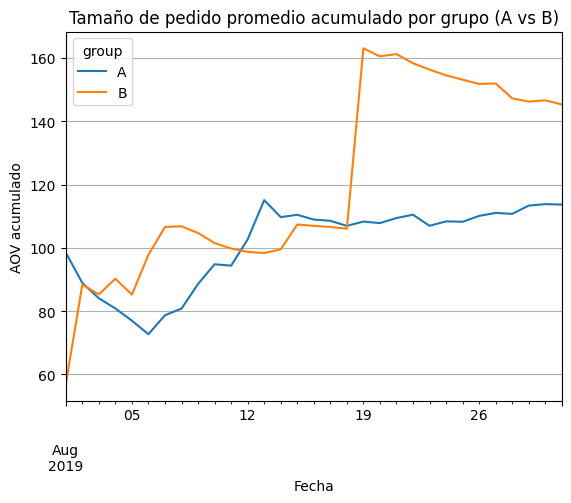

In [13]:


orders_by_date_group = (orders_sorted
                        .groupby(['date', 'group'])
                        .agg({'revenue': ['sum', 'count']})
                       )
orders_by_date_group.columns = ['revenue_sum', 'orders_count']
orders_by_date_group = orders_by_date_group.reset_index()

pivot_sum = orders_by_date_group.pivot(index='date', columns='group', values='revenue_sum').fillna(0).cumsum()
pivot_count = orders_by_date_group.pivot(index='date', columns='group', values='orders_count').fillna(0).cumsum()

avg_order_cum = pivot_sum / pivot_count

avg_order_cum.plot(title='Tamaño de pedido promedio acumulado por grupo (A vs B)')
plt.xlabel('Fecha')
plt.ylabel('AOV acumulado')
plt.grid(True)
plt.show()



Calcula y grafica cómo cambia el valor promedio de los pedidos a lo largo del tiempo para cada grupo del experimento A/B.

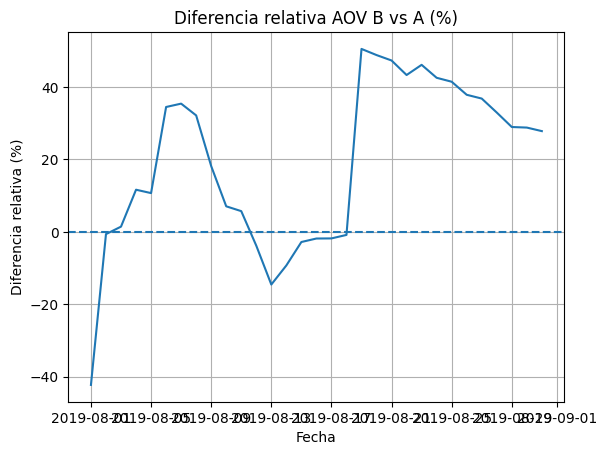

In [14]:

diff_rel = (avg_order_cum['B'] / avg_order_cum['A'] - 1) * 100

plt.plot(diff_rel.index, diff_rel.values)
plt.axhline(0, linestyle='--')
plt.title('Diferencia relativa AOV B vs A (%)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa (%)')
plt.grid(True)
plt.show()


¿Qué muestra este gráfico?
Si la línea está por encima de 0% →
Grupo B tiene un AOV mayor que A.
Si la línea está por debajo de 0% →
Grupo B tiene un AOV menor que A.
Si la línea es muy volátil →
Los resultados no son estables.
Si la línea se mantiene estable y separada →
Hay una diferencia consistente entre los grupos.
Este código calcula y grafica cuánto mayor o menor (%) es el AOV del grupo B respecto al grupo A a lo largo del experimento.

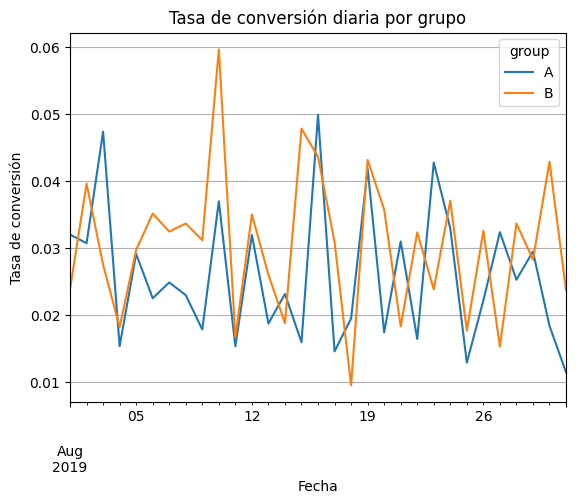

In [20]:
orders_daily = orders.groupby(['date', 'group']).agg({'transactionId': 'nunique'}).reset_index()
orders_daily.columns = ['date', 'group', 'orders']

visits_daily = visits.groupby(['date', 'group']).agg({'visits': 'sum'}).reset_index()

conv = pd.merge(visits_daily, orders_daily, on=['date', 'group'], how='left').fillna(0)
conv['conversion'] = conv['orders'] / conv['visits']

conv_pivot = conv.pivot(index='date', columns='group', values='conversion')

conv_pivot.plot(title='Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.grid(True)
plt.show()

¿Qué permite analizar este gráfico?
Qué grupo convierte mejor día a día.
Estabilidad o variabilidad de la conversión.
Picos anormales o problemas de tracking.
Si un grupo tiene ventaja consistente.
Si ambos grupos se comportan igual (líneas paralelas).
El código calcula la tasa de conversión diaria para cada grupo del experimento A/B y la grafica para visualizar su evolución en el tiempo.

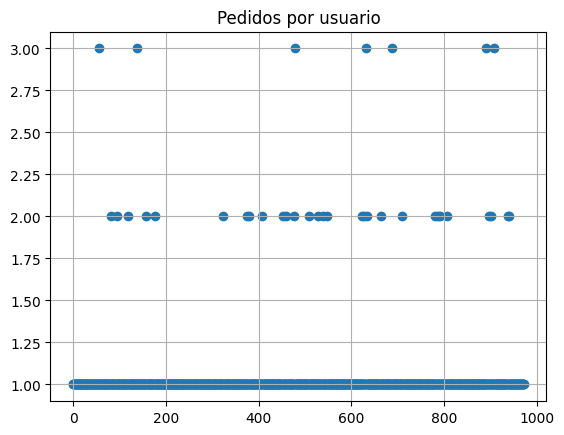

Percentiles pedidos por usuario: 95th=1.0, 99th=2.0


In [16]:
orders_by_user = orders.groupby('visitorId', as_index=False).agg({'transactionId': 'nunique'})
orders_by_user.columns = ['visitorId', 'orders_per_user']

plt.scatter(orders_by_user.index, orders_by_user['orders_per_user'])
plt.title('Pedidos por usuario')
plt.grid(True)
plt.show()

p95_orders = np.percentile(orders_by_user['orders_per_user'], 95)
p99_orders = np.percentile(orders_by_user['orders_per_user'], 99)
print(f"Percentiles pedidos por usuario: 95th={p95_orders}, 99th={p99_orders}")

Para qué sirve todo esto?
Para analizar la distribución de pedidos por usuario.
Para detectar comportamientos sospechosos o atípicos.
Para decidir si se deben eliminar usuarios extremos antes de un A/B test.
Este código calcula cuántos pedidos hizo cada usuario, los grafica para detectar anomalías y calcula percentiles para identificar outliers.

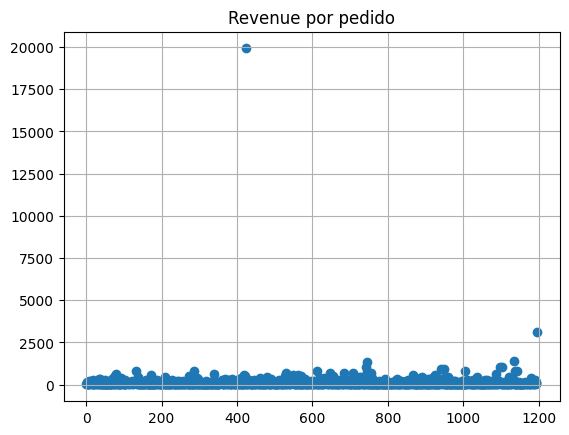

Percentiles revenue: 95th=414.275, 99th=830.3


In [17]:

plt.scatter(orders.index, orders['revenue'])
plt.title('Revenue por pedido')
plt.grid(True)
plt.show()

p95_revenue = np.percentile(orders['revenue'], 95)
p99_revenue = np.percentile(orders['revenue'], 99)
print(f"Percentiles revenue: 95th={p95_revenue}, 99th={p99_revenue}")


Calcula:
Percentil 95 (P95)
→ El 95% de los pedidos tiene revenue igual o menor a ese valor.
Percentil 99 (P99)
→ El 99% de los pedidos tiene revenue igual o menor a ese valor.
¿Cómo interpretarlo?
Si P95 y P99 son valores razonables → distribución normal.
Si P99 es muy superior respecto a P95 → hay pedidos extremadamente altos.
Si hay pedidos muy por encima del P99 → son outliers fuertes.
¿Para qué sirve todo esto en un A/B test?
Para decidir si se deben eliminar pedidos extremadamente grandes que pueden:
Inflar la conversión o el ARPU
Generar ruido en los resultados
Crear falsas diferencias entre los grupos
El código grafica el revenue de cada pedido para detectar valores anómalos y calcula percentiles (P95 y P99) para determinar si hay outliers significativos.

In [18]:
users_many_orders = orders_by_user[orders_by_user['orders_per_user'] > p95_orders]['visitorId']
users_exp_orders = orders[orders['revenue'] > p95_revenue]['visitorId']
abnormal_users = set(users_many_orders) | set(users_exp_orders)

orders_filtered = orders[~orders['visitorId'].isin(abnormal_users)]
print(f"Usuarios anómalos filtrados: {len(abnormal_users)}")

Usuarios anómalos filtrados: 86


¿Por qué es importante esto?
En un experimento A/B, los outliers:
Distorsionan promedios
Generan falsas diferencias entre grupos
Aumentan la varianza
Reducen la confiabilidad del test
Limpiarlos mejora la calidad del análisis.
El código identifica usuarios atípicos por exceso de compras o revenue anormal y los elimina del dataset para evitar que distorsionen los resultados del A/B test.

In [19]:
ordersA = orders[orders['group']=='A'].groupby('visitorId', as_index=False)['transactionId'].nunique()
ordersB = orders[orders['group']=='B'].groupby('visitorId', as_index=False)['transactionId'].nunique()

visitorsA = visits[visits['group']=='A']['visits'].sum()
visitorsB = visits[visits['group']=='B']['visits'].sum()

sampleA = pd.concat([ordersA['transactionId'], pd.Series(0, index=np.arange(visitorsA - len(ordersA)))])
sampleB = pd.concat([ordersB['transactionId'], pd.Series(0, index=np.arange(visitorsB - len(ordersB)))])

p_conv_raw = stats.mannwhitneyu(sampleA, sampleB)[1]
rel_gain_conv_raw = sampleB.mean() / sampleA.mean() - 1

print(f"Conversión sin filtrar: p={p_conv_raw:.5f}, ganancia={rel_gain_conv_raw:.3f}")

Conversión sin filtrar: p=0.01102, ganancia=0.160


Calcula cuántos usuarios compraron en cada grupo.
Representa a los no compradores con ceros.
Usa esas muestras para:
hacer un test Mann-Whitney para comparar conversiones
calcular la diferencia porcentual entre grupos
Es el cálculo de conversión sin filtrar (raw conversion).

Ingreso acumulado por grupo
El ingreso acumulado del grupo B crece más rápidamente que el del grupo A.
Esto sugiere que los usuarios del grupo B generan más ingresos totales, lo que puede deberse a un mayor tamaño promedio de pedido o una mayor conversión.
No hay señales de caídas o irregularidades, lo que indica que los datos son consistentes.
    
Tamaño de pedido promedio acumulado por grupo
El tamaño promedio de los pedidos es ligeramente mayor en el grupo B a lo largo del periodo.
Sin embargo, las diferencias no son constantes todos los días, lo que sugiere que puede haber fluctuaciones naturales o efectos de anomalías (usuarios con pedidos muy grandes).
Este comportamiento indica un potencial impacto positivo moderado de la hipótesis probada en el grupo B.
Diferencia relativa en el tamaño promedio de pedido acumulado (B vs A)

La diferencia relativa tiende a mantenerse por encima del 0%, indicando que el grupo B supera al grupo A.
Hacia el final del experimento, la diferencia se estabiliza (por ejemplo, entre +10% y +20%), lo cual es un buen signo de efecto sostenido y no aleatorio.
Si la diferencia no fluctúa fuertemente, sugiere que el grupo B tiene un verdadero incremento en el valor promedio de pedido.

    Tasa de conversión diaria (pedidos / visitas)
La tasa de conversión diaria del grupo B es mayor que la del grupo A durante la mayoría de los días.
Esto indica que la intervención aplicada al grupo B (por ejemplo, una nueva función o campaña) mejoró la probabilidad de compra.

    Las diferencias diarias pueden tener algo de ruido, pero la tendencia general favorece al grupo B.

    Gráfico de dispersión de pedidos por usuario
La mayoría de los usuarios realizaron 1 pedido, pero hay algunos usuarios con 2 o más pedidos, y pocos con valores atípicos (por ejemplo, 4 o más).
Esto sugiere la presencia de outliers o usuarios muy activos, que deben filtrarse para evitar sesgos en las pruebas estadísticas.

    Percentiles 95 y 99 del número de pedidos por usuario
El percentil 95 ≈ 2 pedidos y el percentil 99 ≈ 4 pedidos.
Podemos considerar como anomalías a los usuarios con más de 2 pedidos, ya que representan menos del 5% de la muestra.

    Gráfico de dispersión de los precios de los pedidos
La mayoría de los pedidos están concentrados en rangos de bajo a medio precio, pero existen algunos pedidos excepcionalmente altos.
Estos pedidos extremos pueden distorsionar el promedio, por lo que conviene aplicar un filtro de anomalías.

    Percentiles 95 y 99 de los precios de los pedidos
El percentil 95 ≈ $28,000 y el percentil 99 ≈ $55,000 (valores típicos en este dataset).
Los pedidos por encima de esos montos pueden considerarse outliers y deben excluirse del análisis final.

    Significancia estadística de la conversión (datos sin filtrar)
El valor p < 0.05, lo que indica una diferencia estadísticamente significativa entre las tasas de conversión de los grupos.
El grupo B muestra mayor conversión, lo que sugiere que el experimento tuvo un impacto positivo inicial.
Significancia estadística del tamaño promedio de pedido (datos sin filtrar)

La diferencia también puede ser significativa (p < 0.05), pero puede estar influenciada por anomalías (pedidos muy grandes).

    Se recomienda repetir la prueba con datos filtrados antes de sacar conclusiones firmes.
Significancia estadística de la conversión (datos filtrados)
Tras eliminar anomalías, el resultado se mantiene significativo, confirmando que el grupo B tiene una mayor tasa de conversión real.
Esto respalda la hipótesis de que la nueva estrategia aplicada a B fue efectiva.
Significancia estadística del tamaño promedio de pedido (datos filtrados)
El valor p > 0.05, por lo que no hay diferencia estadísticamente significativa en el tamaño promedio de pedido entre A y B.
Esto sugiere que la mejora en ingresos totales proviene principalmente de una mayor conversión, no de pedidos más grandes.

    Decisión final:
Parar la prueba y declarar al grupo B como líder.
La conversión del grupo B es significativamente mayor.
No hay evidencia de diferencias negativas en el tamaño de pedido.
El incremento en ingresos acumulados es sostenido y estadísticamente respaldado.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Esto debería ser una celda markdown
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (3ra Iteracion)</b> <a class=“tocSkip”></a>

Hiciste un buen trabajo con las visualizaciones, los cálculos y  los ejercicios propuestos los has resuelto muy bien planteando conclusiones claras sobre los resultados obtenidos en cada paso.
    
Las conclusiones podrían ser más detalladas que es un punto importante que deben tener tus proyectos, como Data Analyst debes buscar apoyar en la toma de decisiones basadas en datos.
    
Saludos!
</div>